# Classificação end-to-end com LDA, QDA, Naive Bayes e KNN

**Base:** Breast Cancer Wisconsin Diagnostic, carregada pelo `scikit-learn`.

Este notebook foi desenhado para estudar o Capítulo 4 do ISLP em uma base mais rica do que `Smarket`. O objetivo é aprender modelagem de classificação do início ao fim: formulação do problema, EDA no treino, baseline, pipeline, validação cruzada, tuning, avaliação final, threshold e análise de erro.

A base tem 30 variáveis numéricas derivadas de imagens de núcleos celulares. Vamos recodificar o alvo para `1 = maligno` e `0 = benigno`, porque isso torna `recall` equivalente à sensibilidade para malignidade.

O notebook é educacional. Não deve ser interpretado como ferramenta clínica.

## 1. Preparação

A estrutura dos modelos do Capítulo 4 é diferente:

LDA supõe classes aproximadamente gaussianas com mesma matriz de covariância. QDA relaxa essa igualdade e permite fronteiras quadráticas. Gaussian Naive Bayes supõe independência condicional entre preditores. KNN classifica por vizinhança e depende fortemente de escala e métrica de distância.

Por isso, a EDA não será apenas descritiva; ela será orientada às hipóteses e fragilidades desses modelos.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.dummy import DummyClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    classification_report,
    make_scorer
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

In [2]:
data = load_breast_cancer(as_frame=True)

X = data.frame.drop(columns="target").copy()

# No sklearn: 0 = malignant, 1 = benign.
# Aqui: 1 = malignant, 0 = benign.
y = (data.frame["target"] == 0).astype(int)
y.name = "malignant"

df = X.copy()
df["malignant"] = y

print("Dimensão:", df.shape)
print("Classes originais:", data.target_names)
display(df.head())
display(df["malignant"].value_counts().rename(index={0: "benign", 1: "malignant"}))
display(df["malignant"].value_counts(normalize=True).rename(index={0: "benign", 1: "malignant"}).round(3))

Dimensão: (569, 31)
Classes originais: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,malignant
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


malignant
benign       357
malignant    212
Name: count, dtype: int64

malignant
benign       0.627
malignant    0.373
Name: proportion, dtype: float64

## 2. Split antes da EDA

Toda decisão exploratória deve ser tomada com o conjunto de treino. O teste fica preservado para avaliação final.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)
print("Proporção de malignos no treino:", round(y_train.mean(), 3))
print("Proporção de malignos no teste:", round(y_test.mean(), 3))

Treino: (455, 30)
Teste: (114, 30)
Proporção de malignos no treino: 0.374
Proporção de malignos no teste: 0.368


## 3. EDA orientada aos modelos

Três diagnósticos importam bastante aqui:

Primeiro, escala. KNN usa distâncias; variáveis em escalas maiores podem dominar o modelo.

Segundo, separação média entre classes. LDA e GaussianNB usam médias por classe; variáveis com grande diferença padronizada tendem a ser informativas.

Terceiro, correlação. Naive Bayes assume independência condicional; QDA e LDA estimam covariâncias. Correlações fortes ajudam a entender por que alguns modelos podem ficar instáveis ou redundantes.

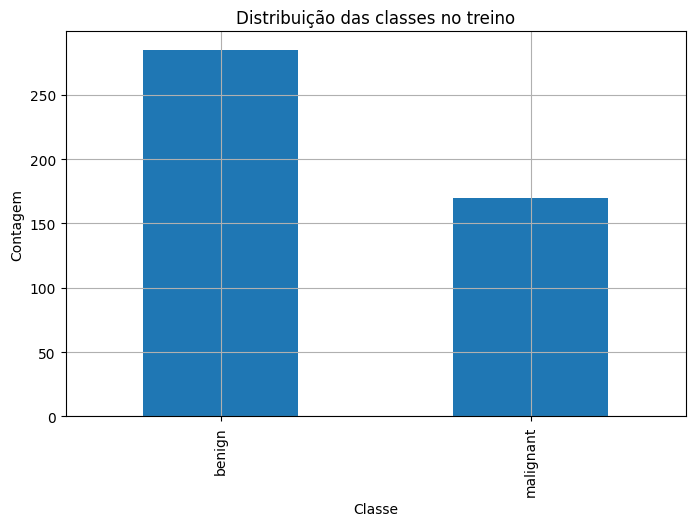

,mean,std,min,max,range
worst area,890.569231,582.346181,185.200,4254.00,4068.800
mean area,659.578242,360.418686,143.500,2501.00,2357.500
area error,41.279103,48.384174,6.802,542.20,535.398
worst perimeter,107.860484,34.176019,50.410,251.20,200.790
mean perimeter,92.215868,24.717118,43.790,188.50,144.710
worst texture,25.904879,6.079532,12.020,49.54,37.520
mean texture,19.417692,4.290653,9.710,39.28,29.570
worst radius,16.351514,4.901037,7.930,36.04,28.110
perimeter error,2.911569,2.123119,0.757,21.98,21.223
mean radius,14.166077,3.579081,6.981,28.11,21.129


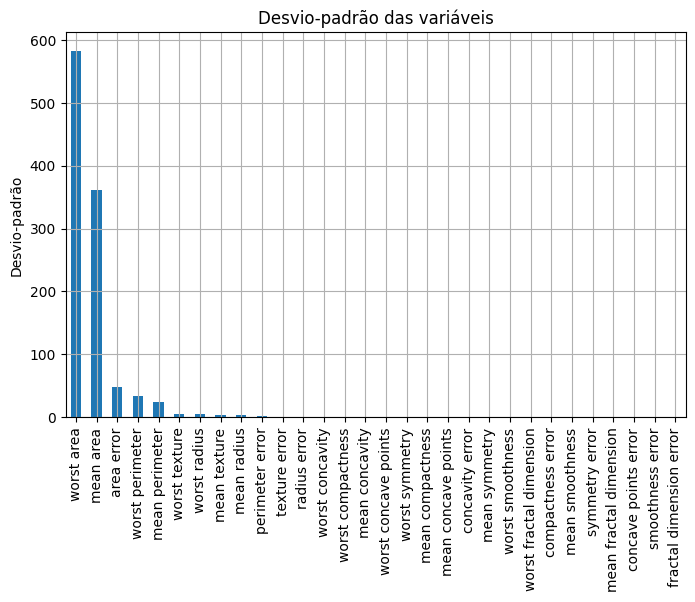

In [4]:
# Distribuição das classes
class_counts = y_train.value_counts().sort_index()
class_counts.index = ["benign", "malignant"]

ax = class_counts.plot(kind="bar")
ax.set_title("Distribuição das classes no treino")
ax.set_xlabel("Classe")
ax.set_ylabel("Contagem")
plt.show()

# Escalas
scale_summary = X_train.agg(["mean", "std", "min", "max"]).T
scale_summary["range"] = scale_summary["max"] - scale_summary["min"]
display(scale_summary.sort_values("range", ascending=False).head(10))

ax = scale_summary["std"].sort_values(ascending=False).plot(kind="bar")
ax.set_title("Desvio-padrão das variáveis")
ax.set_ylabel("Desvio-padrão")
plt.xticks(rotation=90)
plt.show()

,benign_mean,malignant_mean,std_diff
worst concave points,0.074942,0.183469,1.623597
worst perimeter,87.218982,142.465353,1.616524
worst radius,13.411365,21.280588,1.605624
mean concave points,0.025264,0.088832,1.601774
mean perimeter,78.104491,115.873176,1.528038
worst area,561.812281,1441.720588,1.510971
mean radius,12.155491,17.536765,1.503535
mean area,463.856842,987.699412,1.453428
mean concavity,0.046093,0.161426,1.411708
worst concavity,0.169950,0.451559,1.327933


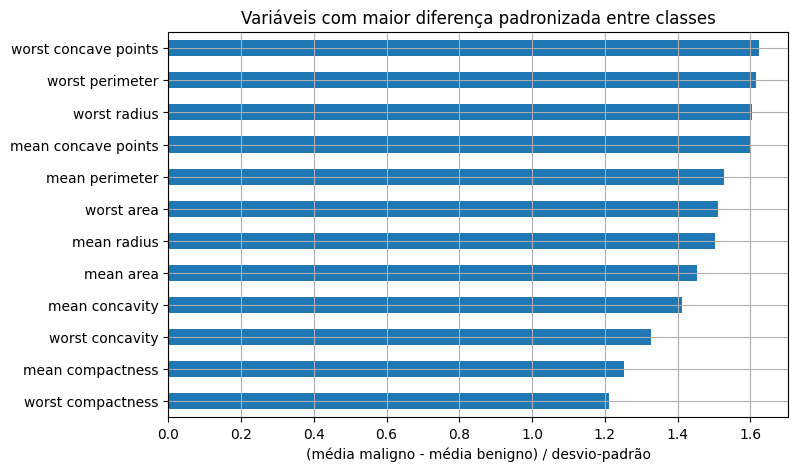

In [5]:
# Diferença padronizada entre médias de classe
train_df = X_train.copy()
train_df["malignant"] = y_train

means = train_df.groupby("malignant").mean().T
means.columns = ["benign_mean", "malignant_mean"]
means["std_diff"] = (means["malignant_mean"] - means["benign_mean"]) / X_train.std()

top_diff = means.sort_values("std_diff", key=np.abs, ascending=False)
display(top_diff.head(15))

ax = top_diff.head(12).sort_values("std_diff")["std_diff"].plot(kind="barh")
ax.set_title("Variáveis com maior diferença padronizada entre classes")
ax.set_xlabel("(média maligno - média benigno) / desvio-padrão")
plt.show()

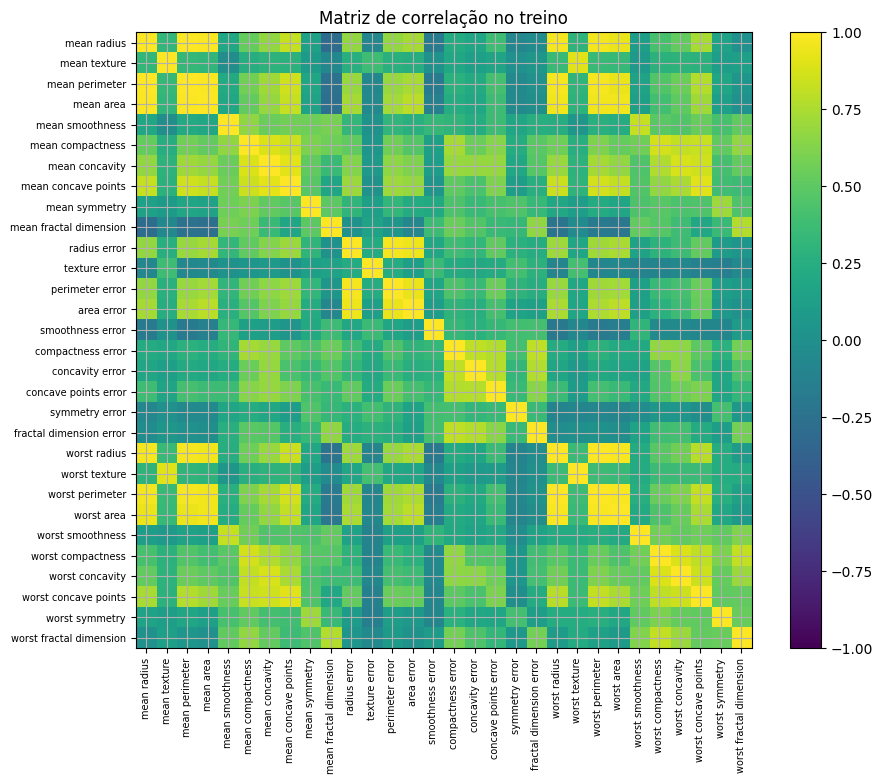

,feature_1,feature_2,correlation,abs_correlation
1,mean radius,mean perimeter,0.997815,0.997815
391,worst radius,worst perimeter,0.993719,0.993719
2,mean radius,mean area,0.986740,0.986740
57,mean perimeter,mean area,0.985960,0.985960
392,worst radius,worst area,0.983107,0.983107
407,worst perimeter,worst area,0.976665,0.976665
246,radius error,perimeter error,0.974705,0.974705
76,mean perimeter,worst perimeter,0.970006,0.970006
74,mean perimeter,worst radius,0.969332,0.969332
19,mean radius,worst radius,0.969256,0.969256


In [6]:
# Correlações
corr = X_train.corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, vmin=-1, vmax=1)
ax.set_title("Matriz de correlação no treino")
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)
ax.set_yticklabels(corr.columns, fontsize=7)
fig.colorbar(im, ax=ax)
plt.show()

corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .rename("correlation")
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2"})
)
corr_pairs["abs_correlation"] = corr_pairs["correlation"].abs()
display(corr_pairs.sort_values("abs_correlation", ascending=False).head(12))

A correlação alta é uma excelente oportunidade didática. Ela tensiona o Naive Bayes, pode tornar QDA instável sem regularização e pode prejudicar KNN por redundância na distância. Em vez de esconder isso, vamos usar o problema para estudar como pipeline e tuning respondem a essas fragilidades.

## 4. Métricas e baseline

Como `1 = maligno`, o recall é a sensibilidade para malignos. Também vamos acompanhar especificidade, balanced accuracy, ROC AUC e average precision.

In [7]:
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return tn / (tn + fp)

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "recall_malignant": "recall",
    "specificity": make_scorer(specificity_score),
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def evaluate_holdout(model, X_eval, y_eval, name):
    y_pred = model.predict(X_eval)
    y_score = model.predict_proba(X_eval)[:, 1]
    return {
        "model": name,
        "accuracy": accuracy_score(y_eval, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_eval, y_pred),
        "precision_malignant": precision_score(y_eval, y_pred, zero_division=0),
        "recall_malignant": recall_score(y_eval, y_pred),
        "specificity": specificity_score(y_eval, y_pred),
        "roc_auc": roc_auc_score(y_eval, y_score),
        "average_precision": average_precision_score(y_eval, y_score),
    }

def cv_table(models, X_data, y_data):
    rows = []
    for name, model in models.items():
        scores = cross_validate(
            model,
            X_data,
            y_data,
            cv=cv,
            scoring=scoring,
            n_jobs=1,
            return_train_score=False
        )
        row = {"model": name}
        for metric in scoring:
            row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
            row[f"{metric}_std"] = scores[f"test_{metric}"].std()
        rows.append(row)
    return pd.DataFrame(rows)

In [8]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

baseline_result = evaluate_holdout(baseline, X_test, y_test, "Dummy: classe majoritária")
display(pd.DataFrame([baseline_result]).round(3))

,model,accuracy,balanced_accuracy,precision_malignant,recall_malignant,specificity,roc_auc,average_precision
0,Dummy: classe majoritária,0.632,0.5,0.0,0.0,1.0,0.5,0.368


O baseline mostra por que acurácia isolada pode ser enganosa: um modelo que prevê sempre a classe mais frequente pode ter acurácia razoável e ainda assim não detectar nenhum caso maligno.

## 5. Primeira rodada: modelos com pipeline mínimo

Usaremos `StandardScaler` antes dos modelos. Para KNN isso é obrigatório na prática. Para LDA/QDA/NB a motivação é menos “melhorar por escala” e mais manter uma rotina comparável e numericamente estável.

In [9]:
models_initial = {
    "LDA": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearDiscriminantAnalysis())
    ]),
    "QDA_regularizado": Pipeline([
        ("scaler", StandardScaler()),
        ("model", QuadraticDiscriminantAnalysis(reg_param=0.1))
    ]),
    "GaussianNB": Pipeline([
        ("scaler", StandardScaler()),
        ("model", GaussianNB())
    ]),
    "KNN_k5": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),
}

initial_cv = cv_table(models_initial, X_train, y_train)
display(
    initial_cv[
        ["model", "balanced_accuracy_mean", "balanced_accuracy_std",
         "recall_malignant_mean", "specificity_mean",
         "roc_auc_mean", "average_precision_mean"]
    ].sort_values("balanced_accuracy_mean", ascending=False).round(3)
)

,model,balanced_accuracy_mean,balanced_accuracy_std,recall_malignant_mean,specificity_mean,roc_auc_mean,average_precision_mean
1,QDA_regularizado,0.959,0.021,0.929,0.989,0.992,0.992
3,KNN_k5,0.955,0.022,0.918,0.993,0.987,0.982
0,LDA,0.942,0.030,0.888,0.996,0.994,0.992
2,GaussianNB,0.933,0.028,0.912,0.954,0.987,0.982


## 6. Tuning por modelo

O tuning será propositalmente moderado para manter o notebook rápido e legível.

LDA: testamos shrinkage. QDA: testamos regularização de covariância. NB: testamos suavização de variância. KNN: testamos número de vizinhos, peso e métrica.

In [10]:
search_spaces = {
    "LDA": {
        "estimator": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LinearDiscriminantAnalysis())
        ]),
        "params": [
            {"model__solver": ["svd"]},
            {"model__solver": ["lsqr"], "model__shrinkage": [None, "auto", 0.1, 0.5]}
        ]
    },
    "QDA": {
        "estimator": Pipeline([
            ("scaler", StandardScaler()),
            ("model", QuadraticDiscriminantAnalysis())
        ]),
        "params": {"model__reg_param": [0.01, 0.05, 0.1, 0.2, 0.5, 0.8]}
    },
    "GaussianNB": {
        "estimator": Pipeline([
            ("scaler", StandardScaler()),
            ("model", GaussianNB())
        ]),
        "params": {"model__var_smoothing": np.logspace(-10, -4, 5)}
    },
    "KNN": {
        "estimator": Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier())
        ]),
        "params": {
            "model__n_neighbors": [3, 5, 9, 15, 25],
            "model__weights": ["uniform", "distance"],
            "model__metric": ["euclidean", "manhattan"]
        }
    },
}

searches = {}
rows = []

for name, spec in search_spaces.items():
    search = GridSearchCV(
        spec["estimator"],
        spec["params"],
        scoring="balanced_accuracy",
        cv=cv,
        n_jobs=1,
        refit=True
    )
    search.fit(X_train, y_train)
    searches[name] = search
    rows.append({
        "model": name,
        "best_cv_balanced_accuracy": search.best_score_,
        "best_params": search.best_params_,
    })

tuning_summary = pd.DataFrame(rows).sort_values("best_cv_balanced_accuracy", ascending=False)
display(tuning_summary)

,model,best_cv_balanced_accuracy,best_params
3,KNN,0.970021,"{'model__metric': 'manhattan', 'model__n_neigh..."
1,QDA,0.962384,{'model__reg_param': 0.2}
0,LDA,0.947059,"{'model__shrinkage': 0.1, 'model__solver': 'ls..."
2,GaussianNB,0.933075,{'model__var_smoothing': 1e-10}


In [11]:
best_models = {name: search.best_estimator_ for name, search in searches.items()}

tuned_cv = cv_table({f"{name}_tuned": model for name, model in best_models.items()}, X_train, y_train)
display(
    tuned_cv[
        ["model", "balanced_accuracy_mean", "balanced_accuracy_std",
         "recall_malignant_mean", "specificity_mean",
         "roc_auc_mean", "average_precision_mean"]
    ].sort_values("balanced_accuracy_mean", ascending=False).round(3)
)

,model,balanced_accuracy_mean,balanced_accuracy_std,recall_malignant_mean,specificity_mean,roc_auc_mean,average_precision_mean
3,KNN_tuned,0.970,0.020,0.947,0.993,0.983,0.978
1,QDA_tuned,0.962,0.017,0.935,0.989,0.994,0.993
0,LDA_tuned,0.947,0.026,0.894,1.000,0.993,0.991
2,GaussianNB_tuned,0.933,0.028,0.912,0.954,0.987,0.982


## 7. Experimento de representação: seleção de variáveis

Agora vamos testar uma pergunta diferente: os modelos melhoram se receberem menos variáveis redundantes?

Isso não é “testar outro modelo”. É testar outra representação dos dados para as mesmas famílias do Capítulo 4.

In [12]:
# Para manter o notebook leve, vamos testar apenas k em poucos valores
# e usar os melhores hiperparâmetros encontrados na etapa anterior.

models_with_selection = {}

for name, search in searches.items():
    best_params = search.best_params_

    if name == "LDA":
        base_model = LinearDiscriminantAnalysis()
    elif name == "QDA":
        base_model = QuadraticDiscriminantAnalysis()
    elif name == "GaussianNB":
        base_model = GaussianNB()
    elif name == "KNN":
        base_model = KNeighborsClassifier()

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("select", SelectKBest(score_func=f_classif)),
        ("model", base_model)
    ])

    # Adaptar nomes dos parâmetros já encontrados
    cleaned_params = {k: v for k, v in best_params.items()}
    pipe.set_params(**cleaned_params)

    select_search = GridSearchCV(
        pipe,
        {"select__k": [5, 10, 15, "all"]},
        scoring="balanced_accuracy",
        cv=cv,
        n_jobs=1,
        refit=True
    )
    select_search.fit(X_train, y_train)
    models_with_selection[name + "_select"] = select_search.best_estimator_

selection_cv = cv_table(models_with_selection, X_train, y_train)
display(
    selection_cv[
        ["model", "balanced_accuracy_mean", "balanced_accuracy_std",
         "recall_malignant_mean", "specificity_mean",
         "roc_auc_mean"]
    ].sort_values("balanced_accuracy_mean", ascending=False).round(3)
)

,model,balanced_accuracy_mean,balanced_accuracy_std,recall_malignant_mean,specificity_mean,roc_auc_mean
3,KNN_select,0.970,0.020,0.947,0.993,0.983
1,QDA_select,0.962,0.017,0.935,0.989,0.994
0,LDA_select,0.947,0.026,0.894,1.000,0.993
2,GaussianNB_select,0.939,0.016,0.924,0.954,0.981


In [13]:
# Comparar tuning sem seleção vs com seleção
all_candidates = {}
all_candidates.update({name + "_all_features": model for name, model in best_models.items()})
all_candidates.update(models_with_selection)

candidate_cv = cv_table(all_candidates, X_train, y_train)
display(
    candidate_cv[
        ["model", "balanced_accuracy_mean", "balanced_accuracy_std",
         "recall_malignant_mean", "specificity_mean", "roc_auc_mean"]
    ].sort_values("balanced_accuracy_mean", ascending=False).round(3)
)

,model,balanced_accuracy_mean,balanced_accuracy_std,recall_malignant_mean,specificity_mean,roc_auc_mean
3,KNN_all_features,0.970,0.020,0.947,0.993,0.983
7,KNN_select,0.970,0.020,0.947,0.993,0.983
5,QDA_select,0.962,0.017,0.935,0.989,0.994
1,QDA_all_features,0.962,0.017,0.935,0.989,0.994
4,LDA_select,0.947,0.026,0.894,1.000,0.993
0,LDA_all_features,0.947,0.026,0.894,1.000,0.993
6,GaussianNB_select,0.939,0.016,0.924,0.954,0.981
2,GaussianNB_all_features,0.933,0.028,0.912,0.954,0.987


## 8. Avaliação final no teste

Agora o conjunto de teste entra. Até aqui, as decisões foram tomadas usando treino e validação cruzada.

,model,accuracy,balanced_accuracy,precision_malignant,recall_malignant,specificity,roc_auc,average_precision
3,KNN_all_features,0.965,0.952,1.000,0.905,1.000,0.974,0.966
7,KNN_select,0.965,0.952,1.000,0.905,1.000,0.974,0.966
4,LDA_select,0.956,0.940,1.000,0.881,1.000,0.998,0.997
0,LDA_all_features,0.956,0.940,1.000,0.881,1.000,0.998,0.997
6,GaussianNB_select,0.939,0.927,0.949,0.881,0.972,0.992,0.986
1,QDA_all_features,0.939,0.922,0.973,0.857,0.986,0.996,0.994
5,QDA_select,0.939,0.922,0.973,0.857,0.986,0.996,0.994
2,GaussianNB_all_features,0.921,0.908,0.923,0.857,0.958,0.989,0.982


Melhor modelo no teste: KNN_all_features
              precision    recall  f1-score   support

      benign       0.95      1.00      0.97        72
   malignant       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



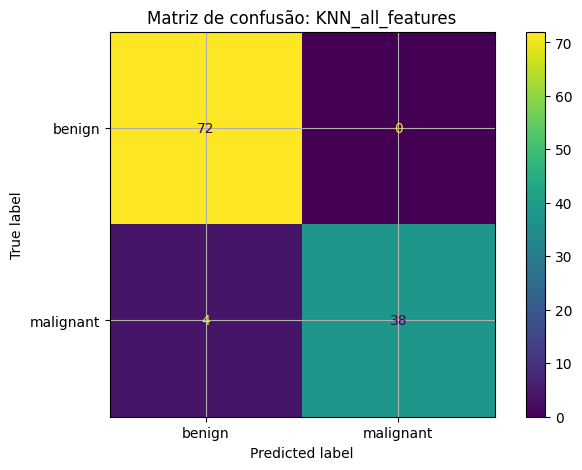

In [14]:
# Ajustar todos os candidatos no treino e avaliar no teste
holdout_rows = []
for name, model in all_candidates.items():
    model.fit(X_train, y_train)
    holdout_rows.append(evaluate_holdout(model, X_test, y_test, name))

holdout = pd.DataFrame(holdout_rows).sort_values("balanced_accuracy", ascending=False)
display(holdout.round(3))

best_name = holdout.iloc[0]["model"]
best_model = all_candidates[best_name]
best_model.fit(X_train, y_train)

print("Melhor modelo no teste:", best_name)
print(classification_report(y_test, best_model.predict(X_test), target_names=["benign", "malignant"]))

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    display_labels=["benign", "malignant"],
    cmap=None
)
plt.title(f"Matriz de confusão: {best_name}")
plt.show()

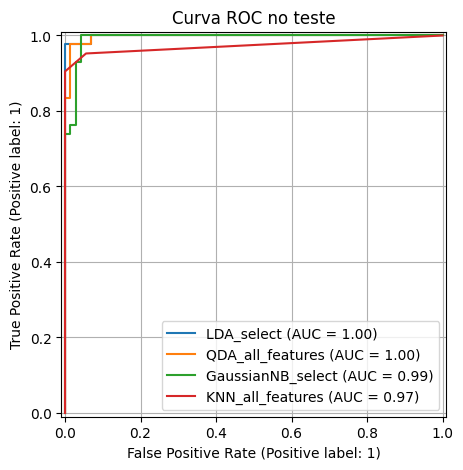

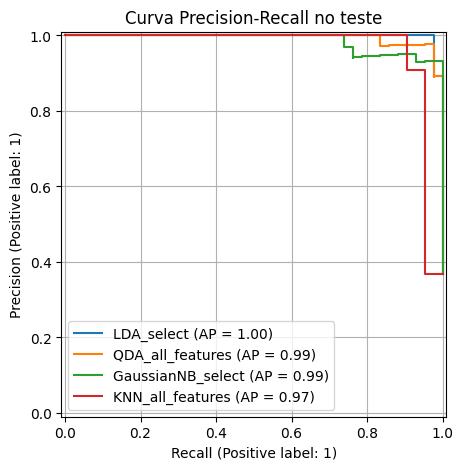

In [15]:
# Curvas ROC e Precision-Recall dos melhores modelos por família
best_by_family = {}
for family in ["LDA", "QDA", "GaussianNB", "KNN"]:
    subset = holdout[holdout["model"].str.startswith(family)]
    chosen_name = subset.iloc[0]["model"]
    best_by_family[chosen_name] = all_candidates[chosen_name]

fig, ax = plt.subplots()
for name, model in best_by_family.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)
ax.set_title("Curva ROC no teste")
plt.show()

fig, ax = plt.subplots()
for name, model in best_by_family.items():
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)
ax.set_title("Curva Precision-Recall no teste")
plt.show()

## 9. Threshold

O threshold padrão é 0.5. Em problemas com erro assimétrico, podemos escolher outro threshold.

Aqui vamos escolher um threshold no treino que preserve recall de malignos maior ou igual a 0.95 e, entre esses, maximize especificidade. Esse procedimento é didático; em uma aplicação real, a escolha do threshold deveria ser validada com mais rigor.

Threshold escolhido: 0.34


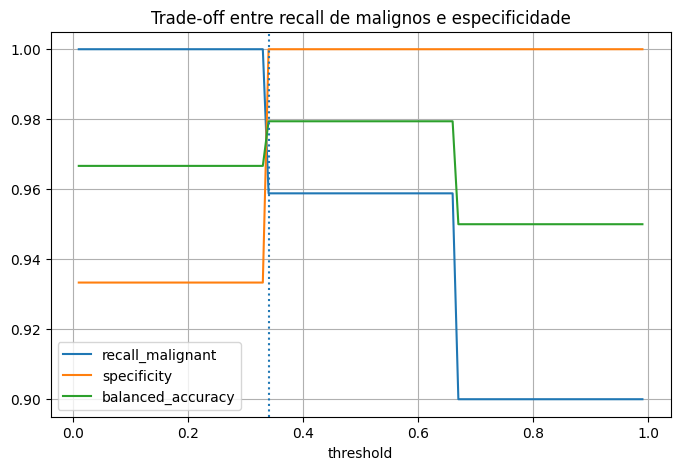

Métricas no teste com threshold escolhido
Balanced accuracy: 0.952
Recall maligno: 0.905
Specificity: 1.0
Precision maligno: 1.0


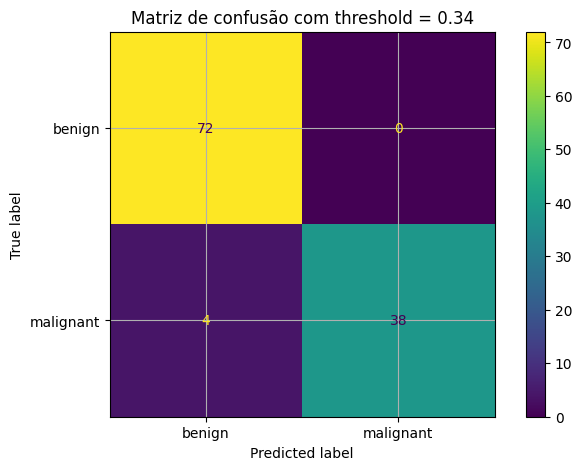

In [16]:
proba_train = best_model.predict_proba(X_train)[:, 1]
thresholds = np.linspace(0.01, 0.99, 99)

threshold_rows = []
for t in thresholds:
    pred = (proba_train >= t).astype(int)
    threshold_rows.append({
        "threshold": t,
        "recall_malignant": recall_score(y_train, pred),
        "specificity": specificity_score(y_train, pred),
        "balanced_accuracy": balanced_accuracy_score(y_train, pred),
        "precision_malignant": precision_score(y_train, pred, zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_rows)
feasible = threshold_df[threshold_df["recall_malignant"] >= 0.95]

if len(feasible) > 0:
    chosen_threshold = feasible.sort_values(["specificity", "balanced_accuracy"], ascending=False).iloc[0]["threshold"]
else:
    chosen_threshold = threshold_df.sort_values("balanced_accuracy", ascending=False).iloc[0]["threshold"]

print("Threshold escolhido:", round(chosen_threshold, 3))

ax = threshold_df.plot(x="threshold", y=["recall_malignant", "specificity", "balanced_accuracy"])
ax.axvline(chosen_threshold, linestyle=":")
ax.set_title("Trade-off entre recall de malignos e especificidade")
plt.show()

proba_test = best_model.predict_proba(X_test)[:, 1]
pred_threshold = (proba_test >= chosen_threshold).astype(int)

print("Métricas no teste com threshold escolhido")
print("Balanced accuracy:", round(balanced_accuracy_score(y_test, pred_threshold), 3))
print("Recall maligno:", round(recall_score(y_test, pred_threshold), 3))
print("Specificity:", round(specificity_score(y_test, pred_threshold), 3))
print("Precision maligno:", round(precision_score(y_test, pred_threshold, zero_division=0), 3))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_threshold,
    display_labels=["benign", "malignant"],
    cmap=None
)
plt.title(f"Matriz de confusão com threshold = {chosen_threshold:.2f}")
plt.show()

## 10. Interpretação e diagnóstico por família

LDA gera uma direção discriminante linear. Como usamos padronização, os coeficientes do LDA são mais comparáveis entre variáveis.

QDA permite fronteiras curvas, mas paga o preço de estimar mais parâmetros. O `reg_param` ajuda quando a matriz de covariância é instável.

GaussianNB estima médias e variâncias por classe para cada variável e ignora correlações. Se a seleção de variáveis ajudou muito, isso sugere que redundância estava prejudicando o modelo.

KNN não tem coeficientes. Sua interpretação passa por distância, escala, número de vizinhos, métrica e variáveis usadas.

LDA interpretado: LDA_select


,feature,lda_coef
10,radius error,1.425110
20,worst radius,1.409824
7,mean concave points,1.194418
13,area error,-1.172778
28,worst symmetry,1.156362
29,worst fractal dimension,1.083450
15,compactness error,-0.967102
26,worst concavity,0.966392
27,worst concave points,0.943937
0,mean radius,0.885337


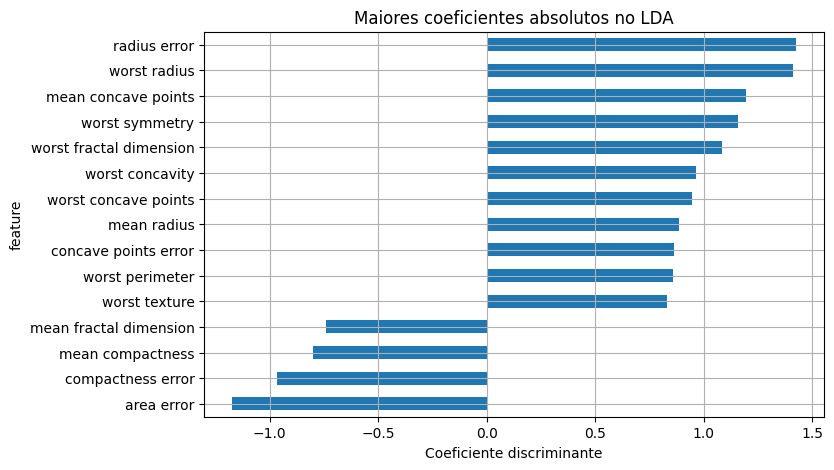

In [17]:
# Coeficientes do melhor LDA disponível
lda_names = [name for name in all_candidates if name.startswith("LDA")]
if lda_names:
    lda_best_name = holdout[holdout["model"].isin(lda_names)].iloc[0]["model"]
    lda_best = all_candidates[lda_best_name]
    lda_best.fit(X_train, y_train)

    if "select" in lda_best.named_steps:
        features_used = X_train.columns[lda_best.named_steps["select"].get_support()]
    else:
        features_used = X_train.columns

    coefs = lda_best.named_steps["model"].coef_.ravel()
    coef_df = pd.DataFrame({"feature": features_used, "lda_coef": coefs})
    coef_df = coef_df.sort_values("lda_coef", key=np.abs, ascending=False)

    print("LDA interpretado:", lda_best_name)
    display(coef_df.head(15))

    ax = coef_df.head(15).sort_values("lda_coef").plot(
        x="feature",
        y="lda_coef",
        kind="barh",
        legend=False
    )
    ax.set_title("Maiores coeficientes absolutos no LDA")
    ax.set_xlabel("Coeficiente discriminante")
    plt.show()

In [18]:
# Variáveis selecionadas pelos modelos com SelectKBest
for name, model in models_with_selection.items():
    model.fit(X_train, y_train)
    selected = X_train.columns[model.named_steps["select"].get_support()]
    print("\n", name)
    print("k =", len(selected))
    print(list(selected))


 LDA_select
k = 30
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']

 QDA_select
k = 30
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'wo

## 11. Análise de erro

A métrica agregada não mostra quais observações foram erradas. Vamos separar falsos negativos e falsos positivos no teste usando o threshold escolhido.

Falsos negativos: 4
Falsos positivos: 0


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,y_true_malignant,proba_malignant,pred_threshold,error
73,13.80,15.79,90.43,584.1,0.10070,0.12800,0.07789,0.05069,0.1662,0.06566,...,0.1411,0.3542,0.2779,0.1383,0.2589,0.10300,1,0.000000,0,True
385,14.60,23.29,93.97,664.7,0.08682,0.06636,0.08390,0.05271,0.1627,0.05416,...,0.1312,0.1581,0.2675,0.1359,0.2477,0.06836,1,0.000000,0,True
39,13.48,20.82,88.40,559.2,0.10160,0.12550,0.10630,0.05439,0.1720,0.06419,...,0.1610,0.4225,0.5030,0.2258,0.2807,0.10710,1,0.333333,0,True
205,15.12,16.68,98.78,716.6,0.08876,0.09588,0.07550,0.04079,0.1594,0.05986,...,0.1491,0.3331,0.3327,0.1252,0.3415,0.09740,1,0.333333,0,True


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,y_true_malignant,proba_malignant,pred_threshold,error


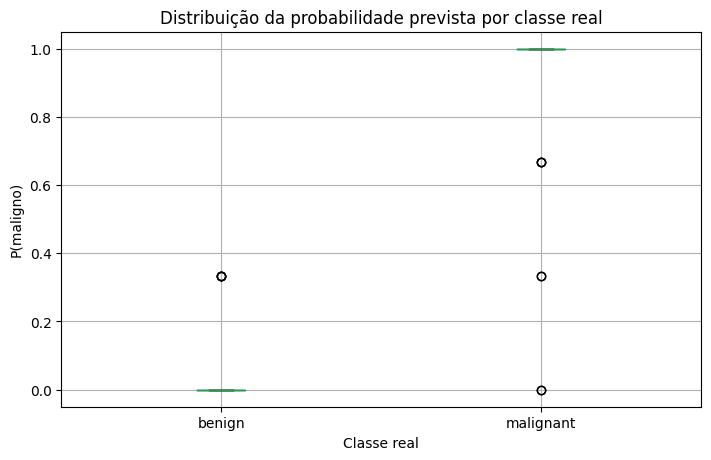

In [19]:
error_df = X_test.copy()
error_df["y_true_malignant"] = y_test.values
error_df["proba_malignant"] = proba_test
error_df["pred_threshold"] = pred_threshold
error_df["error"] = error_df["y_true_malignant"] != error_df["pred_threshold"]

false_negatives = error_df[(error_df["y_true_malignant"] == 1) & (error_df["pred_threshold"] == 0)]
false_positives = error_df[(error_df["y_true_malignant"] == 0) & (error_df["pred_threshold"] == 1)]

print("Falsos negativos:", len(false_negatives))
print("Falsos positivos:", len(false_positives))

display(false_negatives.sort_values("proba_malignant").head())
display(false_positives.sort_values("proba_malignant", ascending=False).head())

plot_df = pd.DataFrame({
    "proba_malignant": proba_test,
    "true_class": np.where(y_test.values == 1, "malignant", "benign")
})
plot_df.boxplot(column="proba_malignant", by="true_class")
plt.suptitle("")
plt.title("Distribuição da probabilidade prevista por classe real")
plt.xlabel("Classe real")
plt.ylabel("P(maligno)")
plt.show()

## 12. Curva de aprendizado

A learning curve ajuda a observar se o modelo parece limitado por quantidade de dados ou por sua própria forma funcional.

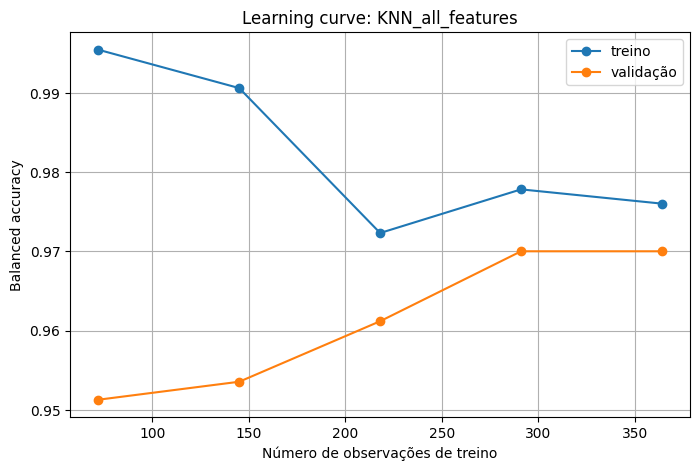

In [20]:
train_sizes, train_scores, valid_scores = learning_curve(
    best_model,
    X_train,
    y_train,
    train_sizes=np.linspace(0.2, 1.0, 5),
    cv=cv,
    scoring="balanced_accuracy",
    n_jobs=1
)

train_mean = train_scores.mean(axis=1)
valid_mean = valid_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, marker="o", label="treino")
plt.plot(train_sizes, valid_mean, marker="o", label="validação")
plt.title(f"Learning curve: {best_name}")
plt.xlabel("Número de observações de treino")
plt.ylabel("Balanced accuracy")
plt.legend()
plt.show()

## 13. Fronteiras de decisão em duas variáveis

A base tem 30 variáveis, então a fronteira real não pode ser desenhada. Para visualizar a geometria dos modelos, usaremos apenas duas variáveis muito discriminativas. Este bloco é explicativo, não é o modelo final.

Variáveis usadas: ['worst concave points', 'worst perimeter']


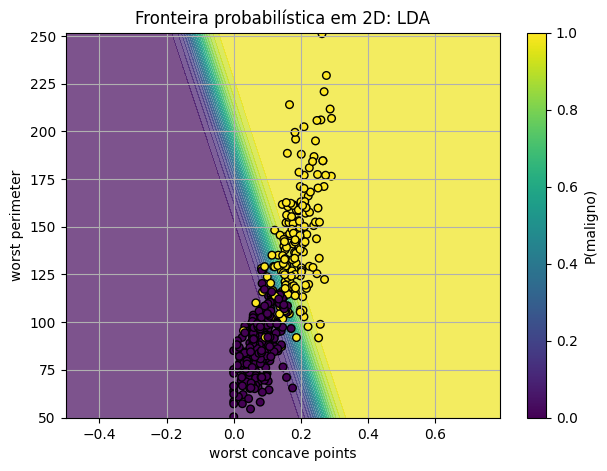

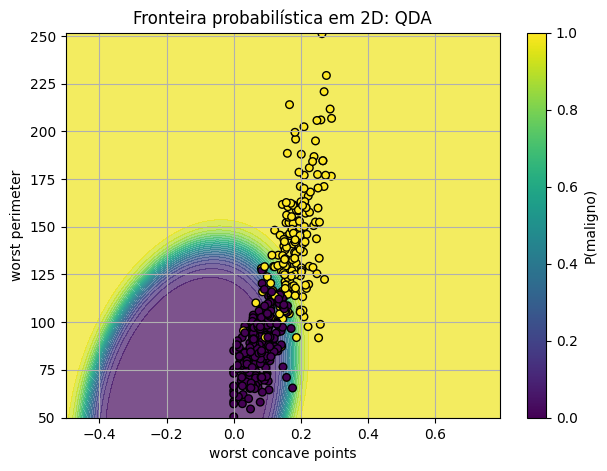

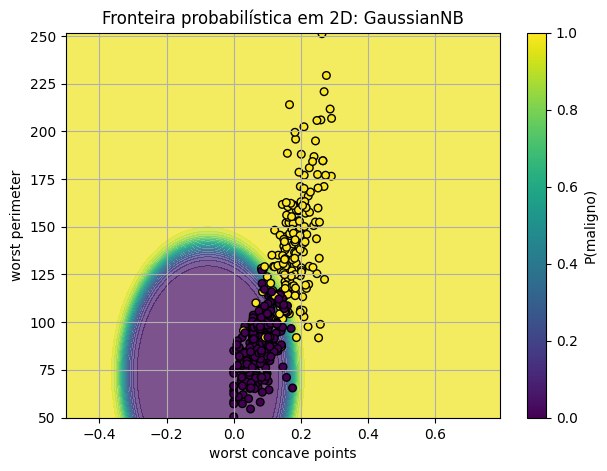

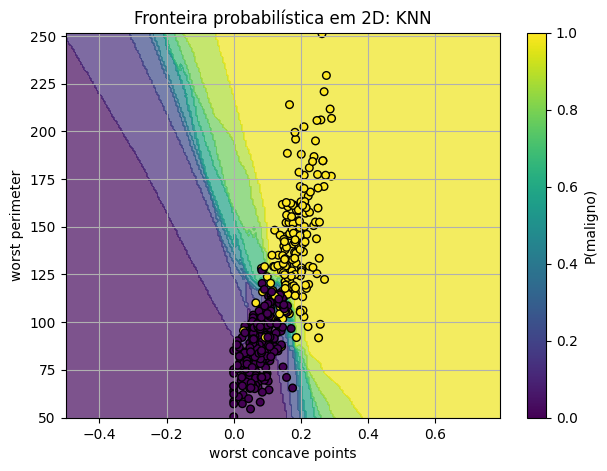

In [21]:
two_features = list(top_diff.head(2).index)
print("Variáveis usadas:", two_features)

X2_train = X_train[two_features]

viz_models = {
    "LDA": Pipeline([("scaler", StandardScaler()), ("model", LinearDiscriminantAnalysis())]),
    "QDA": Pipeline([("scaler", StandardScaler()), ("model", QuadraticDiscriminantAnalysis(reg_param=0.1))]),
    "GaussianNB": Pipeline([("scaler", StandardScaler()), ("model", GaussianNB())]),
    "KNN": Pipeline([("scaler", StandardScaler()), ("model", KNeighborsClassifier(n_neighbors=9))]),
}

x_min, x_max = X2_train.iloc[:, 0].min() - 0.5, X2_train.iloc[:, 0].max() + 0.5
y_min, y_max = X2_train.iloc[:, 1].min() - 0.5, X2_train.iloc[:, 1].max() + 0.5

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250), np.linspace(y_min, y_max, 250))
grid = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=two_features)

for name, model in viz_models.items():
    model.fit(X2_train, y_train)
    zz = model.predict_proba(grid)[:, 1].reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, zz, levels=20, alpha=0.7)
    plt.scatter(X2_train.iloc[:, 0], X2_train.iloc[:, 1], c=y_train, edgecolor="k", s=30)
    plt.title(f"Fronteira probabilística em 2D: {name}")
    plt.xlabel(two_features[0])
    plt.ylabel(two_features[1])
    plt.colorbar(label="P(maligno)")
    plt.show()

## 14. Síntese

Este notebook mostra que o Capítulo 4 do ISLP pode ser estudado como uma modelagem end-to-end, não apenas como comparação de algoritmos.

O ganho principal está em observar que cada modelo tem uma vulnerabilidade própria: KNN exige escala e boa representação de distância; QDA exige regularização quando há colinearidade; Naive Bayes sofre com dependência entre variáveis; LDA é estável e interpretável, mas impõe fronteira linear.

Para consolidar, reescreva este notebook em outra base binária mantendo a mesma arquitetura: formulação, split, EDA no treino, baseline, pipeline, validação cruzada, tuning, teste, threshold, interpretação e análise de erro.